In [1]:
import os

DATASET_PATH = "/kaggle/input"

for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    print("Dirs:", dirs[:5])
    print("Files:", files[:10])
    print("-" * 60)

/kaggle/input
Dirs: ['datasets']
Files: []
------------------------------------------------------------
/kaggle/input/datasets
Dirs: ['alamson']
Files: []
------------------------------------------------------------
/kaggle/input/datasets/alamson
Dirs: ['safebooru']
Files: []
------------------------------------------------------------
/kaggle/input/datasets/alamson/safebooru
Dirs: []
Files: ['all_data.csv']
------------------------------------------------------------


In [2]:
import pandas as pd

CSV_PATH = "/kaggle/input/datasets/alamson/safebooru/all_data.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (3020460, 9)

Columns:
['id', 'created_at', 'rating', 'score', 'sample_url', 'sample_width', 'sample_height', 'preview_url', 'tags']

First 5 rows:


,id,created_at,rating,score,sample_url,sample_width,sample_height,preview_url,tags
0,1,1264803292,s,37,//safebooru.org/samples/1/sample_e7b3dc281d431...,850,638,//safebooru.org/thumbnails/1/thumbnail_e7b3dc2...,1girl bag black_hair blush bob_cut bowieknife ...
1,2,1264803292,s,12,//safebooru.org/samples/1/sample_27ff11b17a2c3...,850,1208,//safebooru.org/thumbnails/1/thumbnail_27ff11b...,barding black cape celty_sturluson dress dulla...
2,3,1264803298,s,8,//safebooru.org/samples/1/sample_ebd16eb1d1547...,850,599,//safebooru.org/thumbnails/1/thumbnail_ebd16eb...,blue_eyes blush brown_hair original scan takoy...
3,4,1264803299,s,5,//safebooru.org/samples/1/sample_6fbb9a4b9099e...,850,519,//safebooru.org/thumbnails/1/thumbnail_6fbb9a4...,game_cg hagall_valkyr mecha_musume shirogane_n...
4,6,1264803304,s,11,//safebooru.org/samples/1/sample_113cb63dc5412...,850,601,//safebooru.org/thumbnails/1/thumbnail_113cb63...,blush idolmaster kisaragi_chihaya komi_zumiko ...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3020460 entries, 0 to 3020459
Data columns (total 9 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   id             int64 
 1   created_at     int64 
 2   rating         object
 3   score          int64 
 4   sample_url     object
 5   sample_width   int64 
 6   sample_height  int64 
 7   preview_url    object
 8   tags           object
dtypes: int64(5), object(4)
memory usage: 207.4+ MB


In [4]:
import pandas as pd

CSV_PATH = "/kaggle/input/datasets/alamson/safebooru/all_data.csv"
df = pd.read_csv(CSV_PATH)

# Basic cleaning
df = df.dropna(subset=["sample_url", "tags"])

# Convert tags to string
df["tags"] = df["tags"].astype(str)

# Keep only safe-rated images
df = df[df["rating"] == "s"]

# Full-body-ish clean subset
required_tags = ["solo", "1girl", "full_body"]

for tag in required_tags:
    df = df[df["tags"].str.contains(rf"\b{tag}\b", regex=True)]

print("Filtered shape:", df.shape)
display(df.head())

Filtered shape: (107537, 9)


,id,created_at,rating,score,sample_url,sample_width,sample_height,preview_url,tags
119644,123972,1267530482,s,0,//safebooru.org/images/124/693d34d28c2fd6ddcff...,580,1000,//safebooru.org/thumbnails/124/thumbnail_693d3...,1girl aqua_eyes armpits blonde_hair bow detach...
125580,130062,1267544148,s,5,//safebooru.org/images/130/9e8ca85f73d0ab19644...,700,783,//safebooru.org/thumbnails/130/thumbnail_9e8ca...,1girl adult bad_id blonde_hair bottle colorful...
137153,141954,1267567737,s,1,//safebooru.org/images/142/2c1bc85f51532063d65...,480,600,//safebooru.org/thumbnails/142/thumbnail_2c1bc...,1girl full_body kagamine_rin mono_(recall) mus...
371676,386353,1273923461,s,3,//safebooru.org/images/386/ced1f4aa364a1808f6c...,746,2216,//safebooru.org/thumbnails/386/thumbnail_ced1f...,1girl :d alpha alpha_(artist) artist_request b...
402267,417239,1274575863,s,0,//safebooru.org/samples/417/sample_c1467fb0b18...,850,1245,//safebooru.org/thumbnails/417/thumbnail_c1467...,1girl absurdres androgynous bags_under_eyes bl...


In [5]:
import pandas as pd

CSV_PATH = "/kaggle/input/datasets/alamson/safebooru/all_data.csv"
df = pd.read_csv(CSV_PATH)

# Basic cleaning
df = df.dropna(subset=["sample_url", "tags"])

# Convert tags to string
df["tags"] = df["tags"].astype(str)

# Keep only safe-rated images
df = df[df["rating"] == "s"]

# Full-body-ish clean subset
required_tags = ["solo", "1girl", "full_body"]

for tag in required_tags:
    df = df[df["tags"].str.contains(rf"\b{tag}\b", regex=True)]

print("Filtered shape:", df.shape)
display(df.head())

Filtered shape: (107537, 9)


,id,created_at,rating,score,sample_url,sample_width,sample_height,preview_url,tags
119644,123972,1267530482,s,0,//safebooru.org/images/124/693d34d28c2fd6ddcff...,580,1000,//safebooru.org/thumbnails/124/thumbnail_693d3...,1girl aqua_eyes armpits blonde_hair bow detach...
125580,130062,1267544148,s,5,//safebooru.org/images/130/9e8ca85f73d0ab19644...,700,783,//safebooru.org/thumbnails/130/thumbnail_9e8ca...,1girl adult bad_id blonde_hair bottle colorful...
137153,141954,1267567737,s,1,//safebooru.org/images/142/2c1bc85f51532063d65...,480,600,//safebooru.org/thumbnails/142/thumbnail_2c1bc...,1girl full_body kagamine_rin mono_(recall) mus...
371676,386353,1273923461,s,3,//safebooru.org/images/386/ced1f4aa364a1808f6c...,746,2216,//safebooru.org/thumbnails/386/thumbnail_ced1f...,1girl :d alpha alpha_(artist) artist_request b...
402267,417239,1274575863,s,0,//safebooru.org/samples/417/sample_c1467fb0b18...,850,1245,//safebooru.org/thumbnails/417/thumbnail_c1467...,1girl absurdres androgynous bags_under_eyes bl...


In [6]:
hair_labels = [
    "black_hair",
    "blonde_hair",
    "brown_hair",
    "blue_hair",
    "pink_hair",
    "white_hair"
]

for label in hair_labels:
    count = df["tags"].str.contains(rf"\b{label}\b", regex=True).sum()
    print(label, ":", count)

black_hair : 14202
blonde_hair : 19031
brown_hair : 17435
blue_hair : 8774
pink_hair : 7497
white_hair : 5422


In [7]:
samples_per_class = 500

subset_list = []

for label in hair_labels:
    temp = df[df["tags"].str.contains(rf"\b{label}\b", regex=True)].copy()
    temp["label"] = label
    
    if len(temp) > samples_per_class:
        temp = temp.sample(samples_per_class, random_state=42)
    
    subset_list.append(temp)

subset_df = pd.concat(subset_list).reset_index(drop=True)

print("Final subset shape:", subset_df.shape)
print(subset_df["label"].value_counts())

display(subset_df[["id", "sample_url", "label", "tags"]].head())

Final subset shape: (3000, 10)
label
black_hair     500
blonde_hair    500
brown_hair     500
blue_hair      500
pink_hair      500
white_hair     500
Name: count, dtype: int64


,id,sample_url,label,tags
0,2310502,//safebooru.org/images/2217/294ef4801fa5c3590a...,black_hair,1girl arrow azutarou black_hair black_legwear ...
1,2918523,https://safebooru.org/samples/2802/sample_e606...,black_hair,1girl bangs black_eyes black_hair bulletproof_...
2,2629440,https://safebooru.org/samples/2522/sample_450f...,black_hair,1girl absurdres alternate_costume azur_lane ba...
3,2796082,https://safebooru.org/images/2685/5c5b90ab3fe5...,black_hair,1girl :d animal_ears animal_hat bangs black_bo...
4,2628714,https://safebooru.org/images/2521/794f9712710e...,black_hair,1girl batta_(ijigen_debris) black_eyes black_h...


In [8]:
def fix_url(url):
    url = str(url)
    if url.startswith("//"):
        return "https:" + url
    elif url.startswith("http"):
        return url
    else:
        return "https://" + url

subset_df["image_url"] = subset_df["sample_url"].apply(fix_url)

display(subset_df[["id", "image_url", "label"]].head(10))

,id,image_url,label
0,2310502,https://safebooru.org/images/2217/294ef4801fa5...,black_hair
1,2918523,https://safebooru.org/samples/2802/sample_e606...,black_hair
2,2629440,https://safebooru.org/samples/2522/sample_450f...,black_hair
3,2796082,https://safebooru.org/images/2685/5c5b90ab3fe5...,black_hair
4,2628714,https://safebooru.org/images/2521/794f9712710e...,black_hair
5,1374164,https://safebooru.org/samples/1321/sample_ae2a...,black_hair
6,1928723,https://safebooru.org/images/1846/b61645c30354...,black_hair
7,1840860,https://safebooru.org/samples/1759/sample_c4c5...,black_hair
8,2374824,https://safebooru.org/images/2280/d089bcc519e1...,black_hair
9,2450571,https://safebooru.org/samples/2353/sample_c85c...,black_hair


In [9]:
subset_df[["id", "image_url", "label", "tags"]].to_csv(
    "safebooru_filtered_metadata.csv",
    index=False
)

print("Saved safebooru_filtered_metadata.csv")

Saved safebooru_filtered_metadata.csv


In [10]:
test_subset_df = subset_df.groupby("label").head(100).reset_index(drop=True)

print(test_subset_df["label"].value_counts())
print("Total test images:", len(test_subset_df))

label
black_hair     100
blonde_hair    100
brown_hair     100
blue_hair      100
pink_hair      100
white_hair     100
Name: count, dtype: int64
Total test images: 600


In [11]:
import os
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm

SAVE_DIR = "safebooru_subset/images"
os.makedirs(SAVE_DIR, exist_ok=True)

records = []

for idx, row in tqdm(test_subset_df.iterrows(), total=len(test_subset_df)):
    image_id = row["id"]
    url = row["image_url"]
    label = row["label"]
    
    try:
        response = requests.get(url, timeout=10)
        
        if response.status_code == 200:
            img = Image.open(BytesIO(response.content)).convert("RGB")
            img = img.resize((64, 64))
            
            filename = f"{image_id}.jpg"
            save_path = os.path.join(SAVE_DIR, filename)
            img.save(save_path, "JPEG")
            
            records.append({
                "image_path": save_path,
                "label": label
            })
            
    except Exception as e:
        pass

labels_df = pd.DataFrame(records)
labels_df.to_csv("safebooru_subset/labels.csv", index=False)

print("Downloaded images:", len(labels_df))
print(labels_df["label"].value_counts())
display(labels_df.head())

 45%|████▌     | 272/600 [00:34<00:33,  9.87it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
100%|██████████| 600/600 [01:13<00:00,  8.14it/s]

Downloaded images: 501
label
brown_hair     90
black_hair     84
pink_hair      83
blue_hair      82
blonde_hair    81
white_hair     81
Name: count, dtype: int64


,image_path,label
0,safebooru_subset/images/2310502.jpg,black_hair
1,safebooru_subset/images/2918523.jpg,black_hair
2,safebooru_subset/images/2796082.jpg,black_hair
3,safebooru_subset/images/2628714.jpg,black_hair
4,safebooru_subset/images/1374164.jpg,black_hair


In [12]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

labels_df = pd.read_csv("safebooru_subset/labels.csv")

label_to_idx = {label: idx for idx, label in enumerate(sorted(labels_df["label"].unique()))}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

print(label_to_idx)

{'black_hair': 0, 'blonde_hair': 1, 'blue_hair': 2, 'brown_hair': 3, 'pink_hair': 4, 'white_hair': 5}


In [13]:
class SafeBooruDataset(Dataset):
    def __init__(self, csv_file, transform=None, label_to_idx=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path = self.data.iloc[idx]["image_path"]
        label_name = self.data.iloc[idx]["label"]
        label = self.label_to_idx[label_name]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [14]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = SafeBooruDataset(
    csv_file="safebooru_subset/labels.csv",
    transform=transform,
    label_to_idx=label_to_idx
)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

images, labels = next(iter(dataloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 64, 64])
Label batch shape: torch.Size([32])
Sample labels: tensor([5, 5, 1, 0, 2, 1, 5, 1, 0, 2])


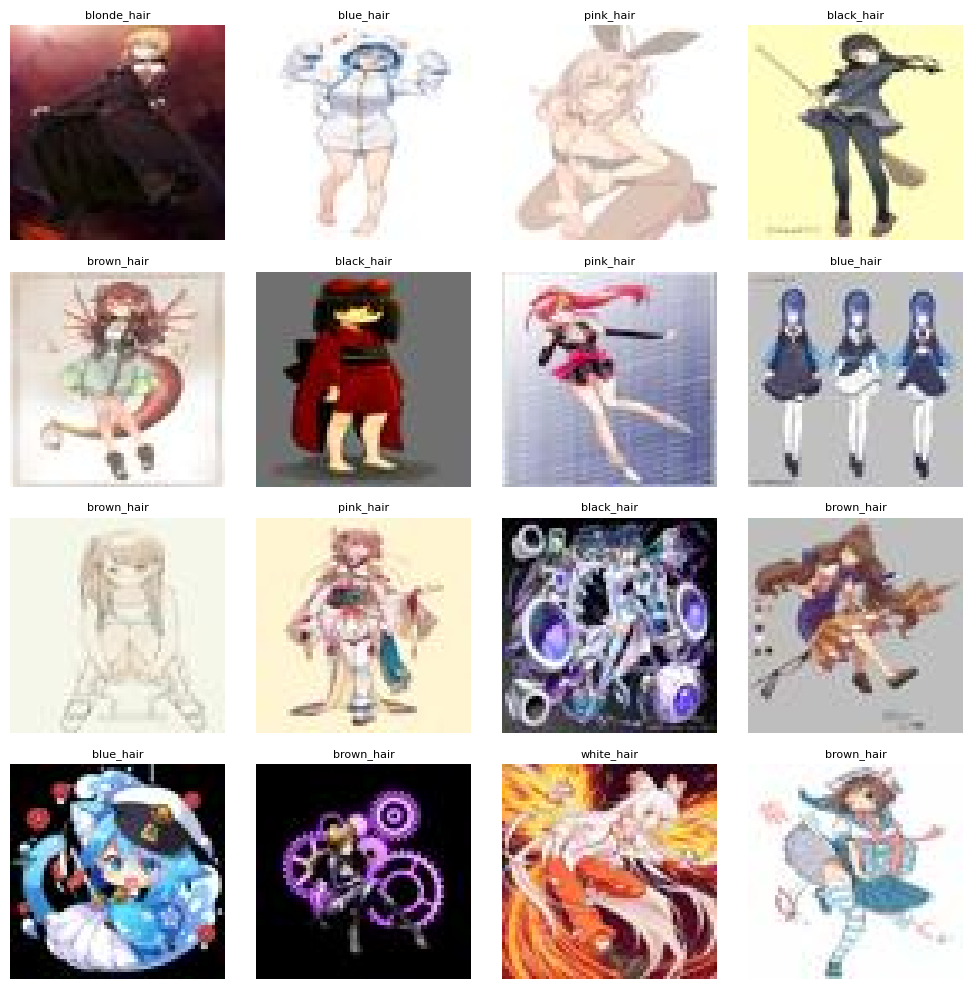

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img * 0.5 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

batch_images, batch_labels = next(iter(dataloader))

plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    imshow(batch_images[i])
    plt.title(idx_to_label[batch_labels[i].item()], fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
import os

BASE_DIR = "/kaggle/working/week5_safebooru"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/datasets/safebooru_subset", exist_ok=True)
os.makedirs(f"{BASE_DIR}/results/conditional_gan_safebooru", exist_ok=True)

In [17]:
labels_df.to_csv(
    f"{BASE_DIR}/datasets/safebooru_subset/labels.csv",
    index=False
)

subset_df[["id", "image_url", "label", "tags"]].to_csv(
    f"{BASE_DIR}/datasets/safebooru_subset/safebooru_filtered_metadata.csv",
    index=False
)

In [18]:
plt.savefig(
    f"{BASE_DIR}/results/conditional_gan_safebooru/week5_sample_batch.png",
    dpi=200
)

<Figure size 640x480 with 0 Axes>